In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)

PROJECT_ROOT = Path(
    r"Z:\Projects\monsoon-postprocessing"
)

PROCESSED_FOLDER = (
    PROJECT_ROOT / "data" / "processed"
)

REGIME_METRICS_FILE = (
    PROCESSED_FOLDER
    / "july2018_regime_correction_metrics.csv"
)

PROBABILITY_METRICS_FILE = (
    PROCESSED_FOLDER
    / "heavy_rain_probability_metrics.csv"
)

EXTREME_METRICS_FILE = (
    PROCESSED_FOLDER
    / "july2018_extreme_metrics.csv"
)

REGIME_CV_FILE = (
    PROCESSED_FOLDER
    / "july2018_regime_cv_predictions.csv"
)

CORRECTION_FILE = (
    PROCESSED_FOLDER
    / "july2018_regime_correction_predictions.nc"
)

PROBABILITY_FILE = (
    PROCESSED_FOLDER
    / "heavy_rain_probability_test.nc"
)

REPORT_FOLDER = PROJECT_ROOT / "outputs" / "verification"
REPORT_FOLDER.mkdir(parents=True, exist_ok=True)

In [2]:
regime_metrics = pd.read_csv(
    REGIME_METRICS_FILE
)

probability_metrics = pd.read_csv(
    PROBABILITY_METRICS_FILE
)

extreme_metrics = pd.read_csv(
    EXTREME_METRICS_FILE
)

regime_cv = pd.read_csv(
    REGIME_CV_FILE
)

print("Regime correction metrics:")
display(regime_metrics)

print("\nProbability metrics:")
display(probability_metrics)

print("\nExtreme-event metrics:")
display(extreme_metrics)

print("\nRegime CV prediction columns:")
print(list(regime_cv.columns))

display(regime_cv.head())

Regime correction metrics:


,model,RMSE,MAE,Bias,Correlation,scope,regime,dates
0,Regime-aware correction,19.283310,9.319411,1.775371,0.418059,overall,All,NaN
1,Global correction,19.293255,9.326070,1.795499,0.418268,overall,All,NaN
2,Raw GEFS,20.383118,10.980301,5.336696,0.428161,overall,All,NaN
3,Raw GEFS,21.823767,11.626359,5.080247,0.510436,per-regime,Active,4.0
4,Global correction,20.835585,10.068924,1.558575,0.505343,per-regime,Active,4.0
5,Regime-aware correction,20.862535,10.109785,1.663127,0.505680,per-regime,Active,4.0
6,Raw GEFS,18.403837,10.193403,5.458880,0.453313,per-regime,Break,9.0
7,Global correction,17.198220,8.376396,1.885100,0.445747,per-regime,Break,9.0
8,Regime-aware correction,17.222940,8.402975,1.944143,0.445636,per-regime,Break,9.0
9,Raw GEFS,23.714779,12.424675,6.058847,0.369575,per-regime,Low/Depression,7.0



Probability metrics:


,event,rainfall_threshold_mm,probability_threshold,Brier_score,ROC_AUC,PR_AUC,hits,misses,false_alarms,CSI,POD,FAR,ETS
0,heavy,64.5,0.10,0.013978,0.909883,0.116839,234,894,1348,0.094507,0.207447,0.852086,0.085788
1,very_heavy,115.6,0.05,0.002035,0.921333,0.030430,12,133,247,0.030612,0.082759,0.953668,0.029382



Extreme-event metrics:


,model,category,threshold_mm,hits,misses,false_alarms,CSI,POD,FAR,ETS,metric_type,neighborhood_cells,approximate_scale_km,FSS
0,Raw GEFS,Heavy,64.5,64.0,1064.0,1241.0,0.027016,0.056738,0.950958,0.018948,categorical,NaN,NaN,NaN
1,Raw GEFS,Very Heavy,115.6,0.0,145.0,161.0,0.000000,0.000000,1.000000,-0.001011,categorical,NaN,NaN,NaN
2,Raw GEFS,Extremely Heavy,204.5,0.0,11.0,3.0,0.000000,0.000000,1.000000,-0.000031,categorical,NaN,NaN,NaN
3,Additive,Heavy,64.5,45.0,1083.0,957.0,0.021583,0.039894,0.955090,0.014513,categorical,NaN,NaN,NaN
4,Additive,Very Heavy,115.6,0.0,145.0,140.0,0.000000,0.000000,1.000000,-0.000943,categorical,NaN,NaN,NaN
5,Additive,Extremely Heavy,204.5,0.0,11.0,3.0,0.000000,0.000000,1.000000,-0.000031,categorical,NaN,NaN,NaN
6,Linear Regression,Heavy,64.5,0.0,1128.0,5.0,0.000000,0.000000,1.000000,-0.000066,categorical,NaN,NaN,NaN
7,Linear Regression,Very Heavy,115.6,0.0,145.0,0.0,0.000000,0.000000,NaN,0.000000,categorical,NaN,NaN,NaN
8,Linear Regression,Extremely Heavy,204.5,0.0,11.0,0.0,0.000000,0.000000,NaN,0.000000,categorical,NaN,NaN,NaN
9,Gradient Boosting,Heavy,64.5,44.0,1084.0,225.0,0.032520,0.039007,0.836431,0.029640,categorical,NaN,NaN,NaN



Regime CV prediction columns:
['date', 'prototype_regime', 'predicted_regime', 'correct']


,date,prototype_regime,predicted_regime,correct
0,2018-07-01,Normal,Break,False
1,2018-07-02,Break,Normal,False
2,2018-07-03,Break,Break,True
3,2018-07-04,Break,Break,True
4,2018-07-05,Break,Break,True


In [3]:
with xr.open_dataset(CORRECTION_FILE) as dataset:
    correction_ds = dataset.load()

with xr.open_dataset(PROBABILITY_FILE) as dataset:
    probability_ds = dataset.load()

print("Correction dataset:")
print(correction_ds)

print("\nProbability dataset:")
print(probability_ds)

Correction dataset:
<xarray.Dataset> Size: 8MB
Dimensions:                    (date: 31, latitude: 129, longitude: 121)
Coordinates:
  * date                       (date) datetime64[ns] 248B 2018-07-01 ... 2018...
  * latitude                   (latitude) float64 1kB 6.0 6.25 ... 37.75 38.0
  * longitude                  (longitude) float64 968B 68.0 68.25 ... 98.0
Data variables:
    raw_gefs_rainfall          (date, latitude, longitude) float32 2MB 1.91 ....
    global_corrected_rainfall  (date, latitude, longitude) float32 2MB 0.0 .....
    regime_corrected_rainfall  (date, latitude, longitude) float32 2MB 0.0 .....
    imerg_rainfall             (date, latitude, longitude) float32 2MB nan .....
Attributes:
    evaluation:         four-fold out-of-fold
    regime_classifier:  Random Forest
    correction:         regime-specific additive bias
    limitations:        Prototype based on 31 dates

Probability dataset:
<xarray.Dataset> Size: 939kB
Dimensions:                      (date:

In [4]:
y_regime_true = regime_cv[
    "prototype_regime"
]

y_regime_predicted = regime_cv[
    "predicted_regime"
]

classifier_summary = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(
                y_regime_true,
                y_regime_predicted,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_regime_true,
                y_regime_predicted,
            ),
            "macro_f1": f1_score(
                y_regime_true,
                y_regime_predicted,
                average="macro",
            ),
            "correct_days": int(
                (y_regime_true == y_regime_predicted).sum()
            ),
            "total_days": len(regime_cv),
        }
    ]
)

regime_confusion = pd.crosstab(
    y_regime_true,
    y_regime_predicted,
    rownames=["Actual"],
    colnames=["Predicted"],
)

display(classifier_summary)
display(regime_confusion)

,accuracy,balanced_accuracy,macro_f1,correct_days,total_days
0,0.548387,0.608856,0.582641,17,31


Predicted,Active,Break,Low/Depression,Normal
Actual,,,,
Active,3,1,0,0
Break,1,5,0,3
Low/Depression,1,0,6,0
Normal,1,7,0,3


In [5]:
def continuous_metrics(observed, predicted):
    valid = (
        np.isfinite(observed)
        & np.isfinite(predicted)
    )

    observation = observed[valid]
    prediction = predicted[valid]

    error = prediction - observation

    return {
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAE": np.mean(np.abs(error)),
        "Bias": np.mean(error),
        "Correlation": np.corrcoef(
            observation,
            prediction,
        )[0, 1],
        "valid_points": len(observation),
    }


def categorical_metrics(
    observed,
    predicted,
    threshold,
):
    valid = (
        np.isfinite(observed)
        & np.isfinite(predicted)
    )

    observation_event = (
        observed[valid] >= threshold
    )

    prediction_event = (
        predicted[valid] >= threshold
    )

    hits = np.sum(
        observation_event & prediction_event
    )

    misses = np.sum(
        observation_event & ~prediction_event
    )

    false_alarms = np.sum(
        ~observation_event & prediction_event
    )

    correct_negatives = np.sum(
        ~observation_event & ~prediction_event
    )

    csi_denominator = (
        hits + misses + false_alarms
    )

    pod_denominator = hits + misses
    far_denominator = hits + false_alarms

    total = (
        hits
        + misses
        + false_alarms
        + correct_negatives
    )

    random_hits = (
        (hits + misses)
        * (hits + false_alarms)
        / total
    )

    ets_denominator = (
        hits
        + misses
        + false_alarms
        - random_hits
    )

    return {
        "hits": int(hits),
        "misses": int(misses),
        "false_alarms": int(false_alarms),
        "CSI": (
            hits / csi_denominator
            if csi_denominator > 0
            else np.nan
        ),
        "POD": (
            hits / pod_denominator
            if pod_denominator > 0
            else np.nan
        ),
        "FAR": (
            false_alarms / far_denominator
            if far_denominator > 0
            else np.nan
        ),
        "ETS": (
            (hits - random_hits) / ets_denominator
            if ets_denominator > 0
            else np.nan
        ),
    }

In [6]:
test_correction = correction_ds.sel(
    date=slice("2018-07-27", "2018-07-31")
)

observation = test_correction[
    "imerg_rainfall"
].values

verification_models = {
    "Raw GEFS": test_correction[
        "raw_gefs_rainfall"
    ].values,
    "Global correction": test_correction[
        "global_corrected_rainfall"
    ].values,
    "Regime-aware correction": test_correction[
        "regime_corrected_rainfall"
    ].values,
}

continuous_results = []

for model_name, prediction in verification_models.items():
    result = continuous_metrics(
        observation,
        prediction,
    )

    result["model"] = model_name
    continuous_results.append(result)

continuous_test_metrics = pd.DataFrame(
    continuous_results
)[
    [
        "model",
        "RMSE",
        "MAE",
        "Bias",
        "Correlation",
        "valid_points",
    ]
].sort_values("RMSE")

display(continuous_test_metrics)

,model,RMSE,MAE,Bias,Correlation,valid_points
1,Global correction,17.222517,8.187625,1.670622,0.385379,75565
2,Regime-aware correction,17.236191,8.201119,1.697651,0.384998,75565
0,Raw GEFS,18.317780,9.901227,5.106373,0.401600,75565


In [7]:
rainfall_thresholds = {
    "Heavy": 64.5,
    "Very Heavy": 115.6,
    "Extremely Heavy": 204.5,
}

categorical_results = []

for model_name, prediction in verification_models.items():
    for category, threshold in rainfall_thresholds.items():
        result = categorical_metrics(
            observation,
            prediction,
            threshold,
        )

        result.update(
            {
                "model": model_name,
                "category": category,
                "threshold_mm": threshold,
            }
        )

        categorical_results.append(result)

categorical_test_metrics = pd.DataFrame(
    categorical_results
)[
    [
        "model",
        "category",
        "threshold_mm",
        "hits",
        "misses",
        "false_alarms",
        "CSI",
        "POD",
        "FAR",
        "ETS",
    ]
]

display(categorical_test_metrics)

,model,category,threshold_mm,hits,misses,false_alarms,CSI,POD,FAR,ETS
0,Raw GEFS,Heavy,64.5,64,1064,1241,0.027016,0.056738,0.950958,0.018948
1,Raw GEFS,Very Heavy,115.6,0,145,161,0.000000,0.000000,1.000000,-0.001011
2,Raw GEFS,Extremely Heavy,204.5,0,11,3,0.000000,0.000000,1.000000,-0.000031
3,Global correction,Heavy,64.5,45,1083,958,0.021572,0.039894,0.955135,0.014499
4,Global correction,Very Heavy,115.6,0,145,140,0.000000,0.000000,1.000000,-0.000943
5,Global correction,Extremely Heavy,204.5,0,11,3,0.000000,0.000000,1.000000,-0.000031
6,Regime-aware correction,Heavy,64.5,46,1082,958,0.022052,0.040780,0.954183,0.014975
7,Regime-aware correction,Very Heavy,115.6,0,145,140,0.000000,0.000000,1.000000,-0.000943
8,Regime-aware correction,Extremely Heavy,204.5,0,11,3,0.000000,0.000000,1.000000,-0.000031


In [8]:
from scipy.ndimage import uniform_filter


def fractions_skill_score(
    observed,
    predicted,
    threshold,
    neighbourhood,
):
    valid = (
        np.isfinite(observed)
        & np.isfinite(predicted)
    )

    observed_event = (
        (observed >= threshold) & valid
    ).astype(float)

    predicted_event = (
        (predicted >= threshold) & valid
    ).astype(float)

    spatial_size = (
        1,
        neighbourhood,
        neighbourhood,
    )

    valid_fraction = uniform_filter(
        valid.astype(float),
        size=spatial_size,
        mode="constant",
        cval=0,
    )

    observed_fraction = uniform_filter(
        observed_event,
        size=spatial_size,
        mode="constant",
        cval=0,
    )

    predicted_fraction = uniform_filter(
        predicted_event,
        size=spatial_size,
        mode="constant",
        cval=0,
    )

    usable = valid_fraction > 0

    observed_fraction[usable] /= (
        valid_fraction[usable]
    )

    predicted_fraction[usable] /= (
        valid_fraction[usable]
    )

    numerator = np.sum(
        (
            predicted_fraction[usable]
            - observed_fraction[usable]
        ) ** 2
    )

    denominator = np.sum(
        predicted_fraction[usable] ** 2
        + observed_fraction[usable] ** 2
    )

    if denominator == 0:
        return np.nan

    return 1 - numerator / denominator

In [9]:
neighbourhoods = [1, 3, 5, 9]
fss_results = []

for model_name, prediction in verification_models.items():
    for category, threshold in rainfall_thresholds.items():
        for neighbourhood in neighbourhoods:
            fss = fractions_skill_score(
                observation,
                prediction,
                threshold,
                neighbourhood,
            )

            fss_results.append(
                {
                    "model": model_name,
                    "category": category,
                    "threshold_mm": threshold,
                    "neighbourhood_cells": neighbourhood,
                    "approximate_scale_km": (
                        neighbourhood * 25
                    ),
                    "FSS": fss,
                }
            )

fss_test_metrics = pd.DataFrame(fss_results)

display(fss_test_metrics)

,model,category,threshold_mm,neighbourhood_cells,approximate_scale_km,FSS
0,Raw GEFS,Heavy,64.5,1,25,0.052610
1,Raw GEFS,Heavy,64.5,3,75,0.085611
2,Raw GEFS,Heavy,64.5,5,125,0.110992
3,Raw GEFS,Heavy,64.5,9,225,0.160596
4,Raw GEFS,Very Heavy,115.6,1,25,0.000000
5,Raw GEFS,Very Heavy,115.6,3,75,0.000000
6,Raw GEFS,Very Heavy,115.6,5,125,0.000000
7,Raw GEFS,Very Heavy,115.6,9,225,0.001588
8,Raw GEFS,Extremely Heavy,204.5,1,25,0.000000
9,Raw GEFS,Extremely Heavy,204.5,3,75,0.000000


In [10]:
continuous_test_metrics.to_csv(
    REPORT_FOLDER
    / "continuous_test_metrics.csv",
    index=False,
)

categorical_test_metrics.to_csv(
    REPORT_FOLDER
    / "categorical_test_metrics.csv",
    index=False,
)

fss_test_metrics.to_csv(
    REPORT_FOLDER
    / "fss_test_metrics.csv",
    index=False,
)

classifier_summary.to_csv(
    REPORT_FOLDER
    / "regime_classifier_summary.csv",
    index=False,
)

regime_confusion.to_csv(
    REPORT_FOLDER
    / "regime_confusion_matrix.csv"
)

print("Verification tables saved.")

Verification tables saved.


In [11]:
print("=" * 75)
print("FINAL VERIFICATION SUMMARY")
print("=" * 75)

print("\n1. REGIME CLASSIFIER PERFORMANCE")
display(
    classifier_summary.round(4)
)

print("\nRegime confusion matrix:")
display(regime_confusion)

print("\n2. CONTINUOUS RAINFALL VERIFICATION")
print("Evaluation period: 27–31 July 2018")
display(
    continuous_test_metrics
    .round(4)
    .reset_index(drop=True)
)

print("\n3. CATEGORICAL EXTREME-RAINFALL VERIFICATION")
display(
    categorical_test_metrics
    .round(4)
    .reset_index(drop=True)
)

print("\n4. FRACTIONS SKILL SCORE")
display(
    fss_test_metrics
    .round(4)
    .reset_index(drop=True)
)

print("\n5. HEAVY-RAIN PROBABILITY VERIFICATION")
display(
    probability_metrics
    .round(4)
    .reset_index(drop=True)
)

print("\n6. HEAVY-RAINFALL FSS COMPARISON")

heavy_fss_summary = (
    fss_test_metrics[
        fss_test_metrics["category"] == "Heavy"
    ]
    .pivot(
        index=[
            "neighbourhood_cells",
            "approximate_scale_km",
        ],
        columns="model",
        values="FSS",
    )
    .reset_index()
)

display(
    heavy_fss_summary.round(4)
)

print("\n7. OVERALL 31-DAY CORRECTION PERFORMANCE")

overall_regime_metrics = regime_metrics[
    regime_metrics["scope"] == "overall"
][
    [
        "model",
        "RMSE",
        "MAE",
        "Bias",
        "Correlation",
    ]
].copy()

display(
    overall_regime_metrics
    .round(4)
    .reset_index(drop=True)
)

print("\n8. PER-REGIME PERFORMANCE")

per_regime_summary = regime_metrics[
    regime_metrics["scope"] == "per-regime"
][
    [
        "regime",
        "model",
        "dates",
        "RMSE",
        "MAE",
        "Bias",
        "Correlation",
    ]
].copy()

display(
    per_regime_summary
    .round(4)
    .reset_index(drop=True)
)

print("=" * 75)
print("SUMMARY COMPLETE")
print("=" * 75)

FINAL VERIFICATION SUMMARY

1. REGIME CLASSIFIER PERFORMANCE


,accuracy,balanced_accuracy,macro_f1,correct_days,total_days
0,0.5484,0.6089,0.5826,17,31



Regime confusion matrix:


Predicted,Active,Break,Low/Depression,Normal
Actual,,,,
Active,3,1,0,0
Break,1,5,0,3
Low/Depression,1,0,6,0
Normal,1,7,0,3



2. CONTINUOUS RAINFALL VERIFICATION
Evaluation period: 27–31 July 2018


...


7. OVERALL 31-DAY CORRECTION PERFORMANCE


,model,RMSE,MAE,Bias,Correlation
0,Regime-aware correction,19.2833,9.3194,1.7754,0.4181
1,Global correction,19.2933,9.3261,1.7955,0.4183
2,Raw GEFS,20.3831,10.9803,5.3367,0.4282



8. PER-REGIME PERFORMANCE


,regime,model,dates,RMSE,MAE,Bias,Correlation
0,Active,Raw GEFS,4.0,21.8238,11.6264,5.0802,0.5104
1,Active,Global correction,4.0,20.8356,10.0689,1.5586,0.5053
2,Active,Regime-aware correction,4.0,20.8625,10.1098,1.6631,0.5057
3,Break,Raw GEFS,9.0,18.4038,10.1934,5.4589,0.4533
4,Break,Global correction,9.0,17.1982,8.3764,1.8851,0.4457
5,Break,Regime-aware correction,9.0,17.2229,8.4030,1.9441,0.4456
6,Low/Depression,Raw GEFS,7.0,23.7148,12.4247,6.0588,0.3696
7,Low/Depression,Global correction,7.0,22.6046,10.8028,2.4026,0.3587
8,Low/Depression,Regime-aware correction,7.0,22.5074,10.6809,2.0885,0.3573
9,Normal,Raw GEFS,11.0,19.0441,10.4700,4.8704,0.4098


SUMMARY COMPLETE


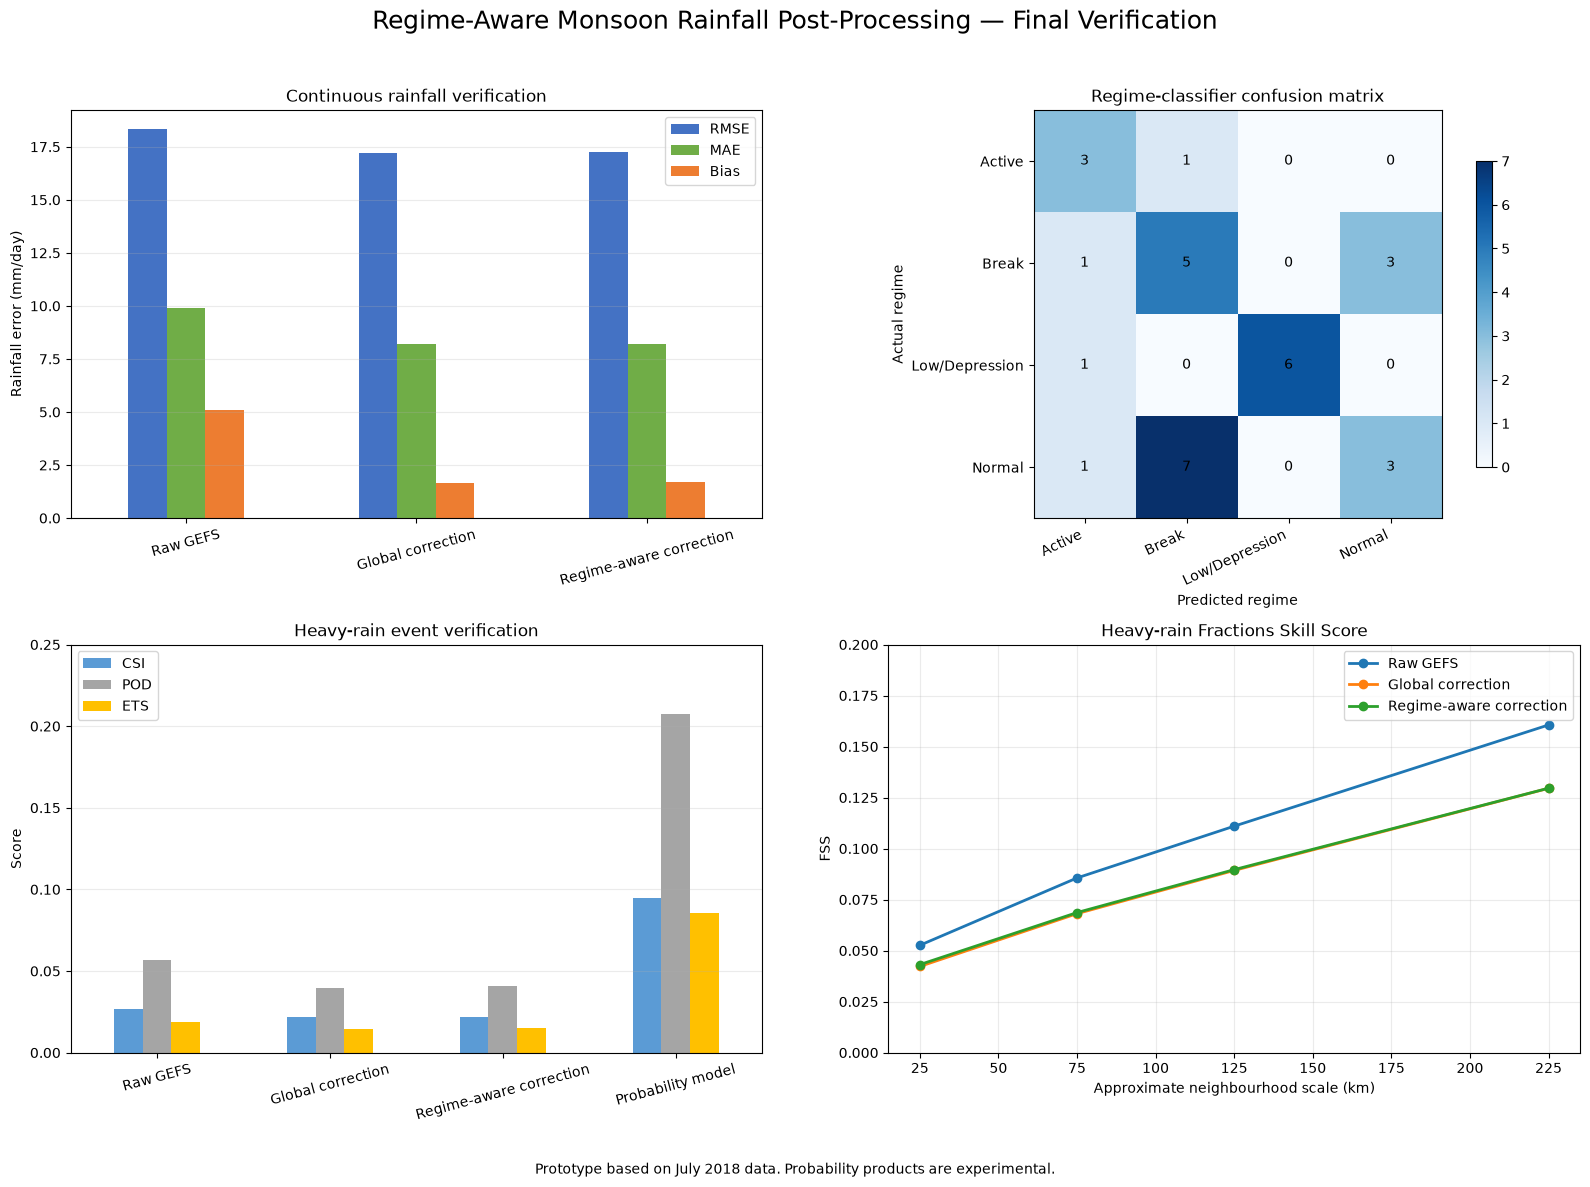

Saved: True
Location: Z:\Projects\monsoon-postprocessing\outputs\verification\final_verification_dashboard.png


In [12]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12),
)

model_order = [
    "Raw GEFS",
    "Global correction",
    "Regime-aware correction",
]

continuous_plot = (
    continuous_test_metrics
    .set_index("model")
    .loc[model_order, ["RMSE", "MAE", "Bias"]]
)

continuous_plot.plot(
    kind="bar",
    ax=axes[0, 0],
    color=["#4472C4", "#70AD47", "#ED7D31"],
)

axes[0, 0].set_title(
    "Continuous rainfall verification"
)
axes[0, 0].set_ylabel("Rainfall error (mm/day)")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(
    axis="x",
    rotation=15,
)
axes[0, 0].grid(
    axis="y",
    alpha=0.25,
)

regime_labels = list(regime_confusion.index)
confusion_values = regime_confusion.values

image = axes[0, 1].imshow(
    confusion_values,
    cmap="Blues",
)

axes[0, 1].set_title(
    "Regime-classifier confusion matrix"
)
axes[0, 1].set_xticks(
    range(len(regime_confusion.columns))
)
axes[0, 1].set_xticklabels(
    regime_confusion.columns,
    rotation=25,
    ha="right",
)
axes[0, 1].set_yticks(
    range(len(regime_labels))
)
axes[0, 1].set_yticklabels(regime_labels)
axes[0, 1].set_xlabel("Predicted regime")
axes[0, 1].set_ylabel("Actual regime")

for row in range(confusion_values.shape[0]):
    for column in range(confusion_values.shape[1]):
        axes[0, 1].text(
            column,
            row,
            confusion_values[row, column],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(
    image,
    ax=axes[0, 1],
    shrink=0.75,
)

heavy_deterministic = categorical_test_metrics[
    categorical_test_metrics["category"] == "Heavy"
][
    ["model", "CSI", "POD", "ETS"]
].copy()

heavy_probability = probability_metrics[
    probability_metrics["event"] == "heavy"
][
    ["CSI", "POD", "ETS"]
].copy()

heavy_probability.insert(
    0,
    "model",
    "Probability model",
)

heavy_comparison = pd.concat(
    [
        heavy_deterministic,
        heavy_probability,
    ],
    ignore_index=True,
).set_index("model")

heavy_comparison.plot(
    kind="bar",
    ax=axes[1, 0],
    color=["#5B9BD5", "#A5A5A5", "#FFC000"],
)

axes[1, 0].set_title(
    "Heavy-rain event verification"
)
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylim(0, 0.25)
axes[1, 0].tick_params(
    axis="x",
    rotation=15,
)
axes[1, 0].grid(
    axis="y",
    alpha=0.25,
)

heavy_fss_plot = fss_test_metrics[
    fss_test_metrics["category"] == "Heavy"
]

for model_name in model_order:
    model_fss = heavy_fss_plot[
        heavy_fss_plot["model"] == model_name
    ]

    axes[1, 1].plot(
        model_fss["approximate_scale_km"],
        model_fss["FSS"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

axes[1, 1].set_title(
    "Heavy-rain Fractions Skill Score"
)
axes[1, 1].set_xlabel(
    "Approximate neighbourhood scale (km)"
)
axes[1, 1].set_ylabel("FSS")
axes[1, 1].set_ylim(0, 0.20)
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

fig.suptitle(
    "Regime-Aware Monsoon Rainfall Post-Processing — "
    "Final Verification",
    fontsize=18,
)

fig.text(
    0.5,
    0.01,
    "Prototype based on July 2018 data. "
    "Probability products are experimental.",
    ha="center",
    fontsize=10,
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.96]
)

VERIFICATION_FIGURE = (
    REPORT_FOLDER
    / "final_verification_dashboard.png"
)

plt.savefig(
    VERIFICATION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", VERIFICATION_FIGURE.exists())
print("Location:", VERIFICATION_FIGURE)

In [13]:
final_summary = pd.DataFrame(
    [
        {
            "component": "Regime classifier",
            "metric": "Balanced accuracy",
            "value": classifier_summary.loc[
                0,
                "balanced_accuracy",
            ],
            "scope": "31 July 2018 days",
        },
        {
            "component": "Regime-aware correction",
            "metric": "31-day RMSE",
            "value": 19.2833,
            "scope": "Four-fold out-of-fold",
        },
        {
            "component": "Raw GEFS",
            "metric": "31-day RMSE",
            "value": 20.3831,
            "scope": "Four-fold out-of-fold",
        },
        {
            "component": "Heavy probability model",
            "metric": "ROC-AUC",
            "value": probability_metrics.loc[
                probability_metrics["event"] == "heavy",
                "ROC_AUC",
            ].iloc[0],
            "scope": "27–31 July 2018",
        },
        {
            "component": "Heavy probability model",
            "metric": "CSI",
            "value": probability_metrics.loc[
                probability_metrics["event"] == "heavy",
                "CSI",
            ].iloc[0],
            "scope": "27–31 July 2018",
        },
        {
            "component": "Heavy probability model",
            "metric": "POD",
            "value": probability_metrics.loc[
                probability_metrics["event"] == "heavy",
                "POD",
            ].iloc[0],
            "scope": "27–31 July 2018",
        },
        {
            "component": "Heavy probability model",
            "metric": "FAR",
            "value": probability_metrics.loc[
                probability_metrics["event"] == "heavy",
                "FAR",
            ].iloc[0],
            "scope": "27–31 July 2018",
        },
    ]
)

FINAL_SUMMARY_FILE = (
    REPORT_FOLDER
    / "final_verification_summary.csv"
)

final_summary.to_csv(
    FINAL_SUMMARY_FILE,
    index=False,
)

display(final_summary.round(4))

print("Saved:", FINAL_SUMMARY_FILE.exists())

,component,metric,value,scope
0,Regime classifier,Balanced accuracy,0.6089,31 July 2018 days
1,Regime-aware correction,31-day RMSE,19.2833,Four-fold out-of-fold
2,Raw GEFS,31-day RMSE,20.3831,Four-fold out-of-fold
3,Heavy probability model,ROC-AUC,0.9099,27–31 July 2018
4,Heavy probability model,CSI,0.0945,27–31 July 2018
5,Heavy probability model,POD,0.2074,27–31 July 2018
6,Heavy probability model,FAR,0.8521,27–31 July 2018


Saved: True
